In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook"

## Mutual Information $I(A:B)$

In [2]:
def I(V_a, V, eta):

    I = 0.5*np.log2(1 + (V_a*eta)/(1 + eta*(V - 1)))
    return I

## Entropy

In [3]:
def S(det):

    A = (np.sqrt(det)+1)/2
    B = (np.sqrt(det)-1)/2

    if B <=0:
        return 0
    
    return A*np.log2(A) - B*np.log2(B)

### $det\boldsymbol{V}_E, \quad \det\boldsymbol{V}_{E|a_x}, \quad \det\boldsymbol{V}_{E|x_B}$

In [4]:
def det_E(V_a, V, eta):

    VEx = (1-eta)*(V + V_a) + eta
    VEp = (1-eta)*(1/V + V_a) + eta
    return VEx*VEp


def det_EA(V_a, V, eta):

    VEx_cond = (1-eta)*V + eta
    VEp = (1-eta)*(1/V + V_a) + eta

    return VEx_cond*VEp

def det_EB(V_a, V, eta):

    VEx_cond = (1-eta)*(V + V_a) + eta - (eta*(1-eta)*(1 - V - V_a)**2)/(eta*(V + V_a) + (1-eta))
    VEp = (1-eta)*(1/V + V_a) + eta

    return VEx_cond*VEp


## Experiment

In [95]:
variance = np.linspace(0, 100, 51)
squeezing= np.linspace(0.1, 1, 51)

### Direct Reconciliation

In [98]:
def K_DR(eta_DR, beta_DR):

    variance = np.linspace(0, 100, 51)
    squeezing= np.linspace(0.1, 1, 51)

    I_DR = np.zeros((variance.size, squeezing.size))
    X_DR = np.zeros((variance.size, squeezing.size))

    for i, V_a in enumerate(variance):
        for j, V in enumerate(squeezing):

            I_DR[i,j] = I(V_a, V, eta_DR)
            X_DR[i,j] = S(det_E(V_a, V, eta_DR)) - S(det_EA(V_a, V, eta_DR))

    return beta_DR*I_DR - X_DR

In [116]:
fig = go.Figure()

variance_mesh, squeezing_mesh = np.meshgrid(variance, squeezing, indexing='ij')

k_dr_green = K_DR(eta_DR=0.9, beta_DR=0.9)
k_dr_gold = K_DR(eta_DR=0.8, beta_DR=0.4)
k_dr_red = K_DR(eta_DR=0.1, beta_DR=0.1)

fig = go.Figure()
fig.add_trace(go.Surface(x=squeezing_mesh, y=variance_mesh, z=k_dr_green, surfacecolor=np.ones_like(k_dr_green), colorscale=[[0, "green"], [1, "green"]],  showscale=False))
fig.add_trace(go.Surface(x=squeezing_mesh, y=variance_mesh, z=k_dr_gold, surfacecolor=np.ones_like(k_dr_gold), colorscale=[[0, "gold"], [1, "gold"]],  showscale=False))
fig.add_trace(go.Surface(x=squeezing_mesh, y=variance_mesh, z=k_dr_red, surfacecolor=np.ones_like(k_dr_red), colorscale=[[0, "red"], [1, "red"]],  showscale=False))
fig.add_trace(go.Surface(x=squeezing_mesh, y=variance_mesh, z=np.zeros((variance.size, squeezing.size)), surfacecolor=np.ones_like(k_dr_gold), colorscale=[[0, "black"], [1, "black"]],  showscale=False))

fig.update_layout(
    scene=dict(xaxis_title="V", yaxis_title="Va", zaxis=dict(title="Key Rate (bits/transmission)"), aspectmode="cube"),width=900,height=750)
fig.show()

## $\eta - \beta$ plot

In [5]:
variance_DR = np.linspace(0, 100, 51)
squeezing_DR = np.linspace(0.1, 1, 51)

eta_DR_grid = np.linspace(0, 1, 51)
beta_DR_grid = np.linspace(0, 1, 101)

In [6]:
beta_th_DR = np.ones(eta_DR_grid.size)

for l, eta_DR in enumerate(eta_DR_grid):

    print(np.round(100*l/(eta_DR_grid.size-1), decimals=2), end="\r")

    for k, beta_DR in enumerate(beta_DR_grid):

        #
        K_DR = np.zeros((variance_DR.size, squeezing_DR.size))

        for i, V_a in enumerate(variance_DR):
            for j, V in enumerate(squeezing_DR):

                I_DR = I(V_a, V, eta_DR)
                X_DR = S(det_E(V_a, V, eta_DR)) - S(det_EA(V_a, V, eta_DR))
                K_DR[i,j] =  beta_DR*I_DR - X_DR
        #
        
        if np.max(K_DR[:, :-1])>0:

            beta_th_DR[l] = beta_DR
            break

In [7]:
beta_th_DR_cs = np.ones(eta_DR_grid.size)

for l, eta_DR in enumerate(eta_DR_grid):

    print(np.round(100*l/(eta_DR_grid.size-1), decimals=2), end="\r")

    for k, beta_DR in enumerate(beta_DR_grid):

        #
        K_DR = np.zeros((variance_DR.size, squeezing_DR.size))

        for i, V_a in enumerate(variance_DR):
            for j, V in enumerate(squeezing_DR):

                I_DR = I(V_a, V, eta_DR)
                X_DR = S(det_E(V_a, V, eta_DR)) - S(det_EA(V_a, V, eta_DR))
                K_DR[i,j] =  beta_DR*I_DR - X_DR
        #
        
        if np.max(K_DR[:, -1])>0:

            beta_th_DR_cs[l] = beta_DR
            break

In [128]:
plt.figure(figsize=(5, 5), dpi=300)
plt.plot(eta_DR_grid, beta_th_DR, linestyle='--', linewidth=2, color='k')
plt.plot(eta_DR_grid, beta_th_DR_cs, linestyle='--', linewidth=2, color='k')

plt.fill_between(eta_DR_grid, 0, beta_th_DR, color='red', alpha=0.7, label='Negative key rates for any squeezing')
plt.fill_between(eta_DR_grid, beta_th_DR, beta_th_DR_cs, color='gold', alpha=0.7, label='Squeezing is necessary for positive key rates')
plt.fill_between(eta_DR_grid, beta_th_DR_cs, 1, color='green', alpha=0.7, label='Squeezing improves positive key rates')

plt.ylabel(r'Direct Reconciliation Effciency $\mathcal{B}_{D}$')
plt.xlabel(r'Transmittance $\eta$')

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=1
)
plt.tight_layout()
plt.savefig("plots/eta-beta_DR.pdf", bbox_inches="tight", dpi=300)
plt.show()



NameError: name 'eta_DR_grid' is not defined

<Figure size 1500x1500 with 0 Axes>

### Reverse Reconciliation

In [122]:
def K_RR(eta_RR, beta_RR):

    variance = np.linspace(0, 100, 51)
    squeezing= np.linspace(0.1, 1, 51)

    I_RR = np.zeros((variance.size, squeezing.size))
    X_RR = np.zeros((variance.size, squeezing.size))

    for i, V_a in enumerate(variance):
        for j, V in enumerate(squeezing):

            I_RR[i,j] = I(V_a, V, eta_RR)
            X_RR[i,j] = S(det_E(V_a, V, eta_RR)) - S(det_EB(V_a, V, eta_RR))

    return beta_RR*I_RR - X_RR

In [127]:
fig = go.Figure()

variance_mesh, squeezing_mesh = np.meshgrid(variance, squeezing, indexing='ij')

k_dr_green = K_RR(eta_RR=0.9, beta_RR=0.9)
k_dr_gold = K_RR(eta_RR=0.4, beta_RR=0.4)
k_dr_red = K_RR(eta_RR=1e-3, beta_RR=1e-3)

fig = go.Figure()
fig.add_trace(go.Surface(x=squeezing_mesh, y=variance_mesh, z=k_dr_green, surfacecolor=np.ones_like(k_dr_green), colorscale=[[0, "green"], [1, "green"]],  showscale=False))
fig.add_trace(go.Surface(x=squeezing_mesh, y=variance_mesh, z=k_dr_gold, surfacecolor=np.ones_like(k_dr_gold), colorscale=[[0, "gold"], [1, "gold"]],  showscale=False))
fig.add_trace(go.Surface(x=squeezing_mesh, y=variance_mesh, z=k_dr_red, surfacecolor=np.ones_like(k_dr_red), colorscale=[[0, "red"], [1, "red"]],  showscale=False))
fig.add_trace(go.Surface(x=squeezing_mesh, y=variance_mesh, z=np.zeros((variance.size, squeezing.size)), surfacecolor=np.ones_like(k_dr_gold), colorscale=[[0, "black"], [1, "black"]],  showscale=False))

fig.update_layout(
    scene=dict(xaxis_title="V", yaxis_title="Va", zaxis=dict(title="Key Rate (bits/transmission)"), aspectmode="cube"),width=900,height=750)
fig.show()

## $\eta - \beta$ plot

In [9]:
variance_RR = np.linspace(0, 100, 101)
squeezing_RR = np.linspace(0.1, 1, 101)

eta_RR_grid = np.linspace(0, 1, 101)
beta_RR_grid = np.linspace(0, 1, 101)

In [10]:
beta_th_RR = np.ones(eta_RR_grid.size)

for l, eta_RR in enumerate(eta_RR_grid):

    print(np.round(100*l/(eta_RR_grid.size-1), decimals=2), end="\r")

    for k, beta_RR in enumerate(beta_RR_grid):

        #
        K_RR = np.zeros((variance_RR.size, squeezing_RR.size))

        for i, V_a in enumerate(variance_RR):
            for j, V in enumerate(squeezing_RR):

                I_RR = I(V_a, V, eta_RR)
                X_RR = S(det_E(V_a, V, eta_RR)) - S(det_EB(V_a, V, eta_RR))
                K_RR[i,j] =  beta_RR*I_RR - X_RR
        #
        
        if np.max(K_RR[:, :-1])>0:

            beta_th_RR[l] = beta_RR
            break

In [11]:
beta_th_RR_cs = np.ones(eta_RR_grid.size)

for l, eta_RR in enumerate(eta_RR_grid):

    print(np.round(100*l/(eta_RR_grid.size-1), decimals=2), end="\r")

    for k, beta_RR in enumerate(beta_RR_grid):

        #
        K_RR = np.zeros((variance_RR.size, squeezing_RR.size))

        for i, V_a in enumerate(variance_RR):
            for j, V in enumerate(squeezing_RR):

                I_RR = I(V_a, V, eta_RR)
                X_RR = S(det_E(V_a, V, eta_RR)) - S(det_EB(V_a, V, eta_RR))
                K_RR[i,j] =  beta_RR*I_RR - X_RR
        #
        
        if np.max(K_RR[:, -1])>0:

            beta_th_RR_cs[l] = beta_RR
            break

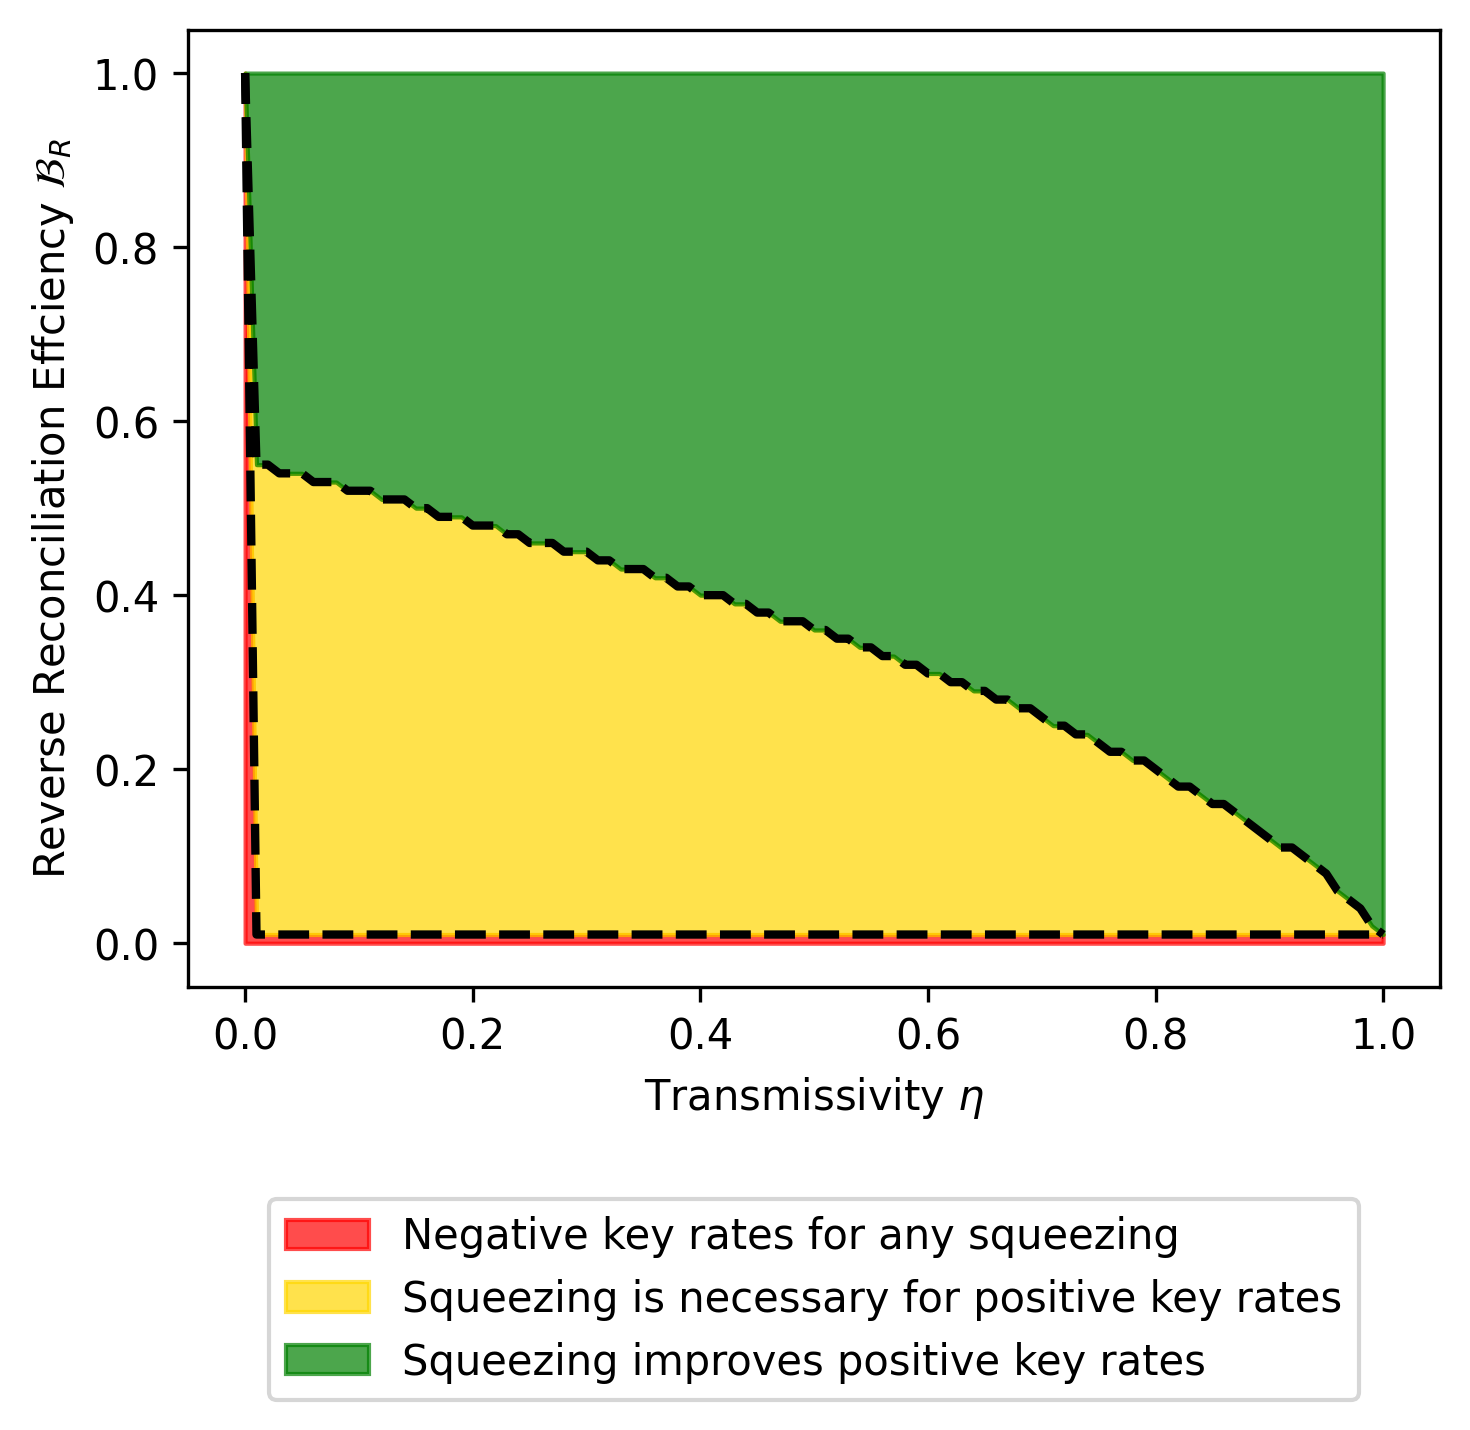

In [14]:
plt.figure(figsize=(5, 5), dpi=300)

plt.plot(eta_RR_grid, beta_th_RR, linestyle='--', linewidth=2, color='k')
plt.plot(eta_RR_grid, beta_th_RR_cs, linestyle='--', linewidth=2, color='k')

plt.fill_between(eta_RR_grid, 0, beta_th_RR, color='red', alpha=0.7, label='Negative key rates for any squeezing')
plt.fill_between(eta_RR_grid, beta_th_RR, beta_th_RR_cs, color='gold', alpha=0.7, label='Squeezing is necessary for positive key rates')
plt.fill_between(eta_RR_grid, beta_th_RR_cs, 1, color='green', alpha=0.7, label='Squeezing improves positive key rates')

plt.ylabel(r'Reverse Reconciliation Effciency $\mathcal{B}_{R}$')
plt.xlabel(r'Transmissivity $\eta$')

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=1
)
plt.tight_layout()
plt.savefig("plots/eta-beta_RR.pdf", bbox_inches="tight", dpi=300)
plt.show()

